In [1]:
#%env JAX_PLATFORMS=cpu
%env CUDA_VISIBLE_DEVICES=0
from typing import Optional, Sequence, Self, Callable, Protocol
import jax
import jax.numpy as jnp
import numpy as np
import equinox as eqx
from jaxtyping import Array, Float, Bool, Int, PRNGKeyArray
import matplotlib.pyplot as plt


env: CUDA_VISIBLE_DEVICES=0


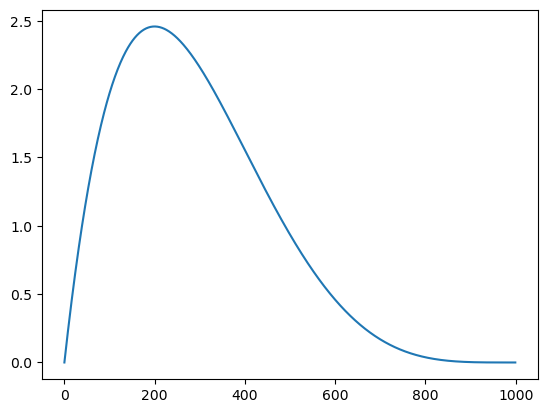

In [2]:
from balif import BetaDistribution
plt.plot(jnp.exp(BetaDistribution(2, 5).logpdf(jnp.linspace(0, 1, 1000))))

In [5]:
jnp.array(0.5)

Array(0.5, dtype=float32, weak_type=True)

In [ ]:
class SplitFn(Protocol):
    def __call__(self, data: Float[Array, "... dim"]) -> Bool[Array, "..."]:
        ...


class HyperplaneSplit(eqx.Module):
    normal: Float[Array, "dim"]
    intercept: Float[Array, ""]

    def __call__(self, data: Float[Array, "... dim"]) -> Bool[Array, "..."]:
        distances = jnp.dot(data, self.normal)
        return distances > self.intercept

    @classmethod
    def sample(
        cls,
        data: Float[Array, "samples dim"],
        mask: Bool[Array, "samples"],
        *,
        key: PRNGKeyArray,
        hyperplane_dim: int,
    ) -> tuple[Self, Bool[Array, "samples"], Bool[Array, "samples"]]:
        _, dim = data.shape
        key_idx, key_value, key_intercept = jax.random.split(key, 3)

        # sample a random normal vector uniformly from the unit sphere
        idxs = jax.random.choice(key_idx, dim, (hyperplane_dim,), replace=False)
        values = jax.random.normal(key_value, (hyperplane_dim,))
        normal = jnp.zeros((dim,)).at[idxs].set(values)

        # sample a random intercept uniformly from the range of the data
        distances = jnp.where(mask, jnp.dot(data, normal), jnp.nan)
        intercept = jax.random.uniform(
            key_intercept, minval=jnp.nanmin(distances), maxval=jnp.nanmax(distances)
        )

        # split the data based on the hyperplane
        left_mask = (distances >= intercept) * mask
        right_mask = (distances <= intercept) * mask
        return cls(normal, intercept), left_mask, right_mask


class EIFTree(eqx.Module):
    reached: Bool[Array, "nodes samples"]
    split_fn: SplitFn # vectorized (nodes,)

    @staticmethod
    def depth(node_id: Int[Array, "..."]) -> Int[Array, "..."]:
        return jnp.log2(1 + node_id).astype(int)

    @staticmethod
    def expected_depth(node_size: Int[Array, "..."]) -> Float[Array, "..."]:
        """Compute the expected isolation depth for a node with n data points."""
        EULER_MASCHERONI = 0.5772156649
        harmonic_number = jax.lax.select(   
            node_size > 1, jnp.log(node_size - 1) + EULER_MASCHERONI, 0.0
        )
        expected_depth = 2 * harmonic_number - 2 * (node_size - 1) / node_size
        return expected_depth

    def path(self, data: Float[Array, "dim"]) -> Int[Array, "max_depth"]:
        def scan_body(node_idx, _):
            split_fn = jax.tree.map(lambda x: x[node_idx], self.split_fn)
            child_idx = jax.lax.select(
                split_fn(data), 2 * node_idx + 1, 2 * node_idx + 2
            )
            return child_idx, node_idx

        max_depth = np.log2(self.reached.shape[0]).astype(int)
        _, path = jax.lax.scan(scan_body, 0, xs=None, length=max_depth)
        return path

    def isolation_node(self, data: Float[Array, "dim"]) -> Int[Array, ""]:
        sizes = self.reached[self.path(data), :].sum(axis=-1)
        return sizes.argmin()

    @classmethod
    def fit(
        cls,
        data: Float[Array, "samples dim"],
        *,
        key: PRNGKeyArray,
        hyperplane_dim: int,
    ) -> Self:
        @eqx.filter_vmap
        def sample_hyperplanes(mask, key):
            return HyperplaneSplit.sample(
                data, mask, key=key, hyperplane_dim=hyperplane_dim
            )

        samples, dim = data.shape
        max_depth = np.ceil(np.log2(samples)).astype(int)
        nodes = 2 ** (max_depth + 1) - 1

        reached = jnp.zeros((nodes, samples), dtype=bool).at[0, :].set(True)
        hyperplanes, _, _ = sample_hyperplanes(reached, jax.random.split(key, nodes))

        for depth, rng_layer in enumerate(jax.random.split(key, max_depth)):
            layer_slice = jnp.arange(2**depth - 1, 2**depth - 1 + 2**depth)

            hyperplanes_at_slice, left_masks, right_masks = sample_hyperplanes(
                reached[layer_slice], jax.random.split(rng_layer, 2**depth)
            )
            hyperplanes = jax.tree.map(
                lambda x, l: x.at[layer_slice].set(l), hyperplanes, hyperplanes_at_slice
            )
            # update the reached masks for the children nodes
            reached = reached.at[2 * layer_slice + 1, :].set(left_masks)
            reached = reached.at[2 * layer_slice + 2, :].set(right_masks)

        return cls(reached, hyperplanes)

In [ ]:
import jax.numpy as jnp
data = jnp.ones((2,))
*batch, dim = data.shape
for i in batch:
    print(i)

In [ ]:
data = jax.random.normal(jax.random.PRNGKey(0), (256, 2))
tree = EIFTree.fit(data, key=jax.random.PRNGKey(0), hyperplane_dim=1)
tree.path(data[0])
tree.isolation_node(data[0])

Array(5, dtype=int32)

In [ ]:
score = lambda tree, x: tree.path(x)[-1]
score = jax.jit(jax.vmap(jax.vmap(score, in_axes=(None, 0)), in_axes=(0, None)))
fit = lambda x: EIFTree.fit(x, key=jax.random.PRNGKey(0), hyperplane_dim=1)
fit = jax.jit(jax.vmap(fit))

In [ ]:
data = jax.random.normal(jax.random.PRNGKey(0), (128, 32, 2))
forest = fit(data)
%timeit fit(data)
print(forest)

data = jax.random.normal(jax.random.PRNGKey(0), (10000, 2))
scores = score(forest, data)
%timeit score(forest, data)
print(scores.shape)

134 µs ± 277 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
EIFTree(
  reached=bool[128,63,32],
  split_fn=HyperplaneSplit(normal=f32[128,63,2], intercept=f32[128,63])
)
446 µs ± 173 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
(128, 10000)


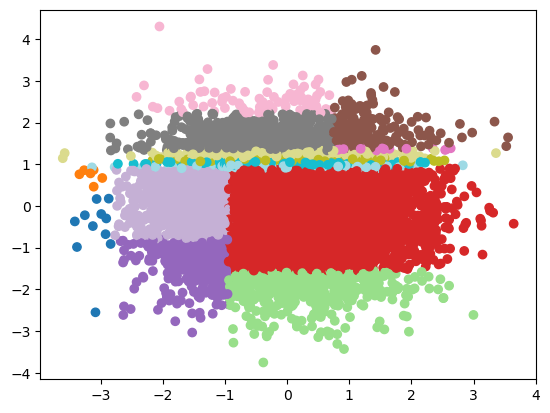

In [ ]:
scores = score(forest, data)[2]
plt.scatter(data[:, 0], data[:, 1], c=scores, cmap="tab20")